In [3]:
# Iniciando sessão Spark
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Studys") \
    .master("local[*]") \
    .getOrCreate()

print("SparkSession iniciada com sucesso")

SparkSession iniciada com sucesso


In [4]:
# Importando Bibliotecas
import sys, os

# Garante que o Spark use o mesmo Python que está rodando o notebook
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, when, count
import pandas as pd

print(f"Python em uso: {sys.executable}")

Python em uso: C:\Users\isabe\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


In [ ]:
%run 01_eda_credit_risk.ipynb

In [ ]:
%run 02_modeling_credit_risk.ipynb

In [ ]:
import pandas as pd

df = pd.read_csv("DataSets/previsoes.csv")

# Análise de Resultados e Insights

In [16]:
# Importância das variáveis (Feature Importance do Random Forest)
rf_model      = pipeline_rf.stages[-1]
importancias  = rf_model.featureImportances.toArray()
n             = len(importancias)

# Extrair nomes reais das features a partir dos metadados do VectorAssembler
sample = pipeline_rf.transform(df_test.limit(1))
attrs  = sample.schema["features_raw"].metadata.get("ml_attr", {}).get("attrs", {})

nomes_reais = [None] * n
for lista in attrs.values():
    for item in lista:
        if item["idx"] < n:
            nomes_reais[item["idx"]] = item["name"]
nomes_reais = [nm if nm else f"feature_{i}" for i, nm in enumerate(nomes_reais)]

df_importancia = pd.DataFrame({
    "feature":    nomes_reais,
    "importancia": importancias
}).sort_values("importancia", ascending=False).head(15)

print("======= Top 15 variáveis mais importantes (Random Forest) =======")
print(df_importancia.to_string(index=False))

======= Top 15 variáveis mais importantes (Random Forest) =======
                                              feature  importancia
                                       anos_empregado     0.173429
                                           idade_anos     0.131291
                         NAME_INCOME_TYPE_ohe_Working     0.084678
                                       prev_recusados     0.079204
             NAME_EDUCATION_TYPE_ohe_Higher education     0.076155
                                      AMT_GOODS_PRICE     0.061465
                                    CODE_GENDER_ohe_F     0.046139
                                  prev_taxa_aprovacao     0.042105
                                faixa_idade_ohe_jovem     0.035645
                                    CODE_GENDER_ohe_M     0.030022
                                           AMT_CREDIT     0.029608
NAME_EDUCATION_TYPE_ohe_Secondary / secondary special     0.018263
                       NAME_INCOME_TYPE_ohe_Pensioner     0.016

In [18]:
# Dentro do perfil do inadimplente, quem tem maior risco?

from pyspark.sql.functions import avg, round as spark_round, abs as spark_abs

df_perfil = df_eda \
    .withColumn("idade_anos", spark_round((spark_abs(col("DAYS_BIRTH"))/ 365), 2).cast("int")) \
    .withColumn("credit_income_ratio",  spark_round(col("AMT_CREDIT") / col("AMT_INCOME_TOTAL"), 2)) \
    .withColumn("annuity_income_ratio", spark_round(col("AMT_ANNUITY") / col("AMT_INCOME_TOTAL"), 2))

perfil = df_perfil.groupBy("TARGET").agg(
    spark_round(avg("AMT_INCOME_TOTAL"),0).alias("renda_media"),
    spark_round(avg("AMT_CREDIT"),0).alias("credito_medio"),
    spark_round(avg("idade_anos"),1).alias("idade_media"),
    spark_round(avg("credit_income_ratio"),3).alias("ratio_credito_renda"),
    spark_round(avg("annuity_income_ratio"),3).alias("ratio_parcela_renda")
).orderBy("TARGET").toPandas()

perfil["TARGET"] = perfil["TARGET"].replace(0, "Adimplente")
perfil["TARGET"] = perfil["TARGET"].replace(1, "Inadimplente")

print("=== Perfil médio: Adimplente vs Inadimplente ===")
print(perfil.set_index("TARGET").T.to_string())

=== Perfil médio: Adimplente vs Inadimplente ===
TARGET               Adimplente  Inadimplente
renda_media          169078.000    165612.000
credito_medio        602648.000    557779.000
idade_media              43.700        40.300
ratio_credito_renda       3.964         3.888
ratio_parcela_renda       0.181         0.186


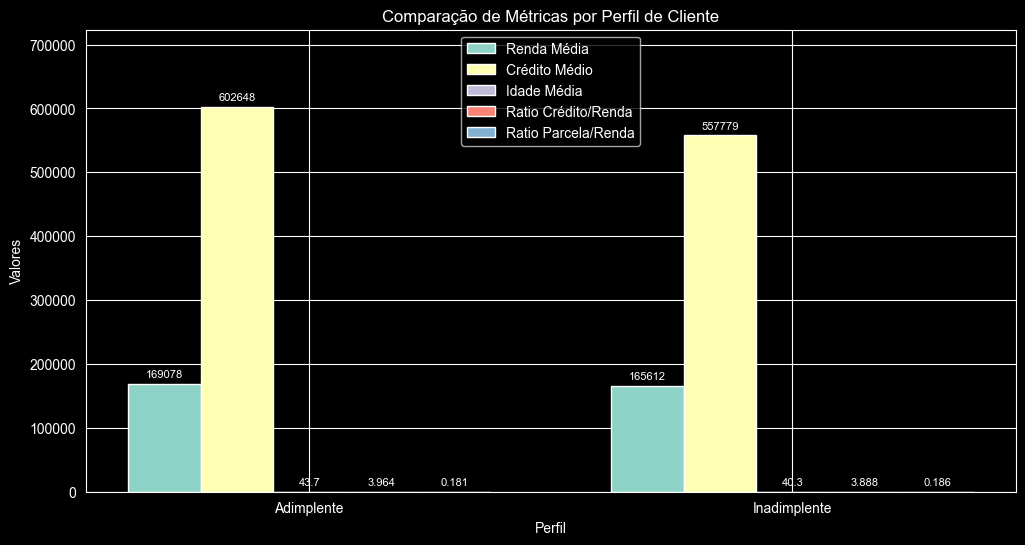

In [36]:
import matplotlib.pyplot as plt
import numpy as np

labels = perfil["TARGET"]
x = np.arange(len(labels))
width = 0.15
plt.figure(figsize=(12,6))

renda = plt.bar(
    x - 2*width,
    perfil["renda_media"],
    width,
    label="Renda Média"
)
credito = plt.bar(
    x - width,
    perfil["credito_medio"],
    width,
    label="Crédito Médio"
)
idade = plt.bar(
    x,
    perfil["idade_media"],
    width,
    label="Idade Média"
)
ratio_credito = plt.bar(
    x + width,
    perfil["ratio_credito_renda"],
    width,
    label="Ratio Crédito/Renda"
)
ratio_parcela = plt.bar(
    x + 2*width,
    perfil["ratio_parcela_renda"],
    width,
    label="Ratio Parcela/Renda"
)
ax = plt.gca()
ax.bar_label(renda, padding=3, fontsize=8)
ax.bar_label(credito, padding=3, fontsize=8)
ax.bar_label(idade, padding=3, fontsize=8)
ax.bar_label(ratio_credito, padding=3, fontsize=8)
ax.bar_label(ratio_parcela, padding=3, fontsize=8)

plt.xticks(x, labels)
plt.title("Comparação de Métricas por Perfil de Cliente")
plt.xlabel("Perfil")
plt.ylabel("Valores")
plt.ylim(0,perfil["credito_medio"].max() * 1.20)
plt.legend(loc="upper center")
plt.show()

In [25]:
# Insights de negócio: renda

print("=== A renda influencia na inadimplência? ===")
df_eda.groupBy("faixa_renda" if "faixa_renda" in df_eda.columns else "TARGET").agg(
    spark_round(avg(col("TARGET").cast("double")) * 100, 2).alias("taxa_inadimplencia (%)")
) if "faixa_renda" in df_eda.columns else None


df_feat.groupBy("faixa_renda").agg(
    count("*").alias("total"),
    spark_round(avg(col("TARGET").cast("double")) * 100, 2).alias("taxa_inadimplencia (%)")
).orderBy("taxa_inadimplencia (%)", ascending=False).show()



=== A renda influencia na inadimplência? ===
+-----------+------+----------------------+
|faixa_renda| total|taxa_inadimplencia (%)|
+-----------+------+----------------------+
|      media|155426|                  8.55|
|      baixa| 35439|                  8.15|
|       alta|103029|                  7.63|
| muito_alta| 13617|                  5.82|
+-----------+------+----------------------+



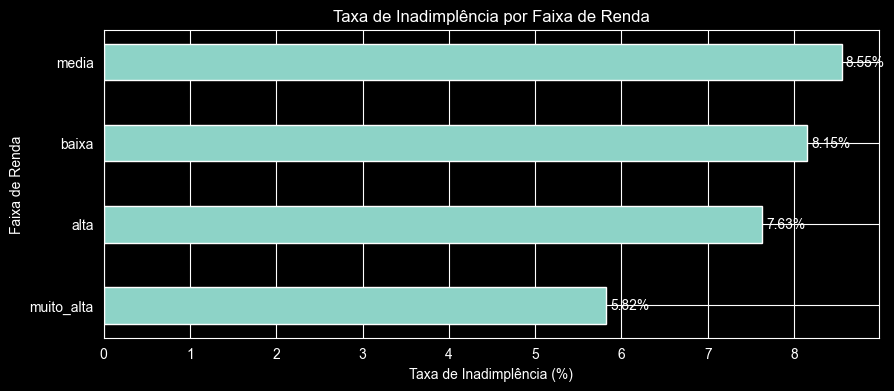

In [62]:
import matplotlib.pyplot as plt


df_pd = (
    df_feat
    .groupBy("faixa_renda")
    .agg(
        count("*").alias("total"),
        spark_round(
            avg(col("TARGET").cast("double")) * 100, 2).alias("taxa_inadimplencia")
    )
    .orderBy("taxa_inadimplencia", ascending=False)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10,4))

bars = ax.barh(
    df_pd["faixa_renda"],
    df_pd["taxa_inadimplencia"],
    height=0.45
)

ax.bar_label(
    bars,
    padding=3,
    fmt="%.2f%%"
)

ax.set_title("Taxa de Inadimplência por Faixa de Renda")
ax.set_xlabel("Taxa de Inadimplência (%)")
ax.set_ylabel("Faixa de Renda")

ax.invert_yaxis()

plt.show()

In [28]:
print("============ A influencia escolaridade =============")
df_eda.groupBy("NAME_EDUCATION_TYPE").agg(
    count("*").alias("total"),
    spark_round(avg(col("TARGET").cast("double")) * 100, 2).alias("taxa_inadimplencia (%)")
).orderBy("taxa_inadimplencia (%)", ascending=False).show()

============ A influencia escolaridade =============
+--------------------+------+----------------------+
| NAME_EDUCATION_TYPE| total|taxa_inadimplencia (%)|
+--------------------+------+----------------------+
|     Lower secondary|  3816|                 10.93|
|Secondary / secon...|218391|                  8.94|
|   Incomplete higher| 10277|                  8.48|
|    Higher education| 74863|                  5.36|
|     Academic degree|   164|                  1.83|
+--------------------+------+----------------------+



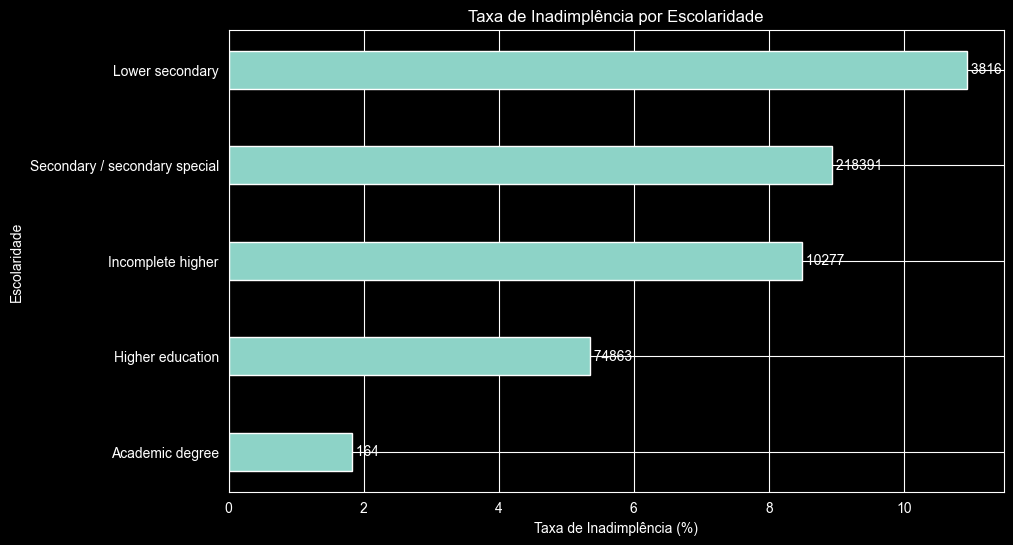

In [64]:
df_pd = df_eda.groupBy("NAME_EDUCATION_TYPE").agg(
    count("*").alias("total"),
    (avg(col("TARGET").cast("double")) * 100).alias("taxa_inadimplencia")
).orderBy("taxa_inadimplencia", ascending=False).toPandas()

plt.figure(figsize=(10,6))

plt.barh(df_pd["NAME_EDUCATION_TYPE"], df_pd["taxa_inadimplencia"], height=0.4)

plt.title("Taxa de Inadimplência por Escolaridade")
plt.xlabel("Taxa de Inadimplência (%)")
plt.ylabel("Escolaridade")

# quantidade nas barras
for i, (taxa, total) in enumerate(zip(df_pd["taxa_inadimplencia"], df_pd["total"])):
    plt.text(taxa, i, f" {total}", va='center')

plt.gca().invert_yaxis()

plt.show()

In [32]:
print("=== Influencia do Histórico de atraso ====")
df_final.withColumn("tem_atraso", when(col("bureau_flag_atraso") == 1, "Sim").otherwise("Não")) \
    .groupBy("tem_atraso").agg(
        count("*").alias("total"),
        spark_round(avg(col("TARGET").cast("double")) * 100, 2).alias("taxa_inadimplencia (%)")
    ).orderBy("tem_atraso").show()

===== Influencia do Histórico de atraso ====
+----------+------+----------------------+
|tem_atraso| total|taxa_inadimplencia (%)|
+----------+------+----------------------+
|       Não|304177|                  7.98|
|       Sim|  3334|                  16.2|
+----------+------+----------------------+



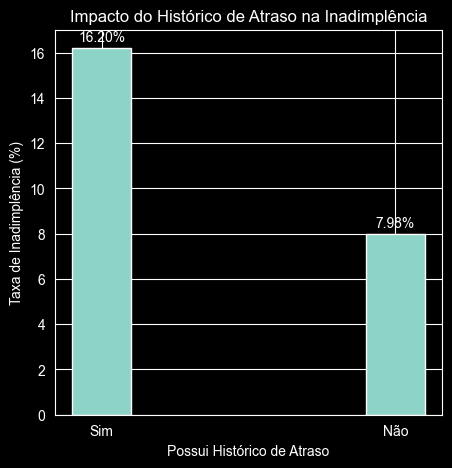

In [65]:
import matplotlib.pyplot as plt

df_pd = (
    df_final
    .withColumn("tem_atraso", when(col("bureau_flag_atraso") == 1, "Sim").otherwise("Não"))
    .groupBy("tem_atraso")
    .agg(
        count("*").alias("total"),
        spark_round(avg(col("TARGET").cast("double")) * 100, 2).alias("taxa_inadimplencia")
    )
    .orderBy("taxa_inadimplencia", ascending=False)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(5,5))
bars = ax.bar(
    df_pd["tem_atraso"],
    df_pd["taxa_inadimplencia"],
    width=0.2
)
ax.bar_label(
    bars,
    padding=3,
    fmt="%.2f%%"
)

ax.set_title("Impacto do Histórico de Atraso na Inadimplência")
ax.set_xlabel("Possui Histórico de Atraso")
ax.set_ylabel("Taxa de Inadimplência (%)")

plt.show()

In [33]:
# Conclusões e resumo dos insights
print("=" * 60)
print("INSIGHTS FINAIS DO PROJETO")
print("=" * 60)
print("""
PERGUNTA: Quem tem maior risco de inadimplência?

PERFIL DO INADIMPLENTE:
  -> Renda mais baixa que a média dos adimplentes
  -> Mais jovem (faixa jovem/adulto)
  -> Proporção crédito/renda mais alta (quanto do crédito representa em relação à renda)
  -> Menor escolaridade
  -> Histórico de atraso em outros créditos (tabela bureau)

VARIÁVEIS QUE MAIS INFLUENCIAM O MODELO:
  -> Variáveis financeiras: renda, crédito, parcela
  -> Ratio crédito/renda e parcela/renda
  -> Histórico externo (bureau): total em atraso, total de créditos
  -> Variáveis demográficas: idade e tempo de emprego

RESPOSTA DE NEGÓCIO:
  O banco deve ter maior cautela com clientes que:
  1. Pedem crédito alto em relação à sua renda
  2. Têm histórico de atraso em outros bancos
  3. São jovens com pouco tempo de emprego
  4. Têm baixa escolaridade combinada com alta dívida
""")

INSIGHTS FINAIS DO PROJETO

PERGUNTA: Quem tem maior risco de inadimplência?

PERFIL DO INADIMPLENTE:
  -> Renda mais baixa que a média dos adimplentes
  -> Mais jovem (faixa jovem/adulto)
  -> Proporção crédito/renda mais alta (quanto do crédito representa em relação à renda)
  -> Menor escolaridade
  -> Histórico de atraso em outros créditos (tabela bureau)

VARIÁVEIS QUE MAIS INFLUENCIAM O MODELO:
  -> Variáveis financeiras: renda, crédito, parcela
  -> Ratio crédito/renda e parcela/renda
  -> Histórico externo (bureau): total em atraso, total de créditos
  -> Variáveis demográficas: idade e tempo de emprego

RESPOSTA DE NEGÓCIO:
  O banco deve ter maior cautela com clientes que:
  1. Pedem crédito alto em relação à sua renda
  2. Têm histórico de atraso em outros bancos
  3. São jovens com pouco tempo de emprego
  4. Têm baixa escolaridade combinada com alta dívida

